# Denoising Autoencoder (Salt & Pepper) on Oxford-IIIT Pet — PyTorch

Plain convolutional autoencoder with **no skip connections**, ported from Keras to PyTorch. The encoder uses three downsampling stages, starting at 64 channels and doubling to 256, reaching a 256-channel 16×16 bottleneck for 128×128 inputs.

## Plan
| # | Step | What happens |
|---|------|--------------|
| 1 | Setup | Imports, config (image size, noise level, epochs), device |
| 2 | Data | Load the repository's local Oxford-IIIT Pet images and official train / val / test splits |
| 3 | Noise | GPU function adding salt & pepper noise on the fly; visual sanity check |
| 4 | Model | No-skip convolutional autoencoder with a 256-channel 16×16 bottleneck |
| 5 | Train | Adam + weighted L1/SSIM loss, fresh noise every batch, track train/val loss |
| 6 | Curves | Plot loss, pick best epoch |
| 7 | Test | PSNR and SSIM on the held-out test split: noisy vs. denoised |
| 8 | Visuals | Noisy / denoised / clean grid |
| 9 | Robustness | Sweep noise density to see how the model copes with levels it wasn't trained on |
| 10 | Baseline | Compare against a 3×3 median filter (the classic S&P fix) |
| 11 | Save | Save and reload weights |

**Differences from the article:** noise is regenerated every batch (not fixed once), salt & pepper replaces Gaussian, and the model is evaluated with PSNR/SSIM as the article's "What Next?" suggests.


## 1. Setup

In [1]:
!pip install -q torchmetrics scipy

import time, random, json
from pathlib import Path
import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from torchmetrics.image import StructuralSimilarityIndexMeasure
from torchmetrics.functional import structural_similarity_index_measure

# ---------------- config ----------------
IMG_SIZE    = 128      # the article uses 240; 128 is faster and lighter on memory
BATCH_SIZE  = 32
EPOCHS      = 30
LR          = 1e-3
TRAIN_NOISE = 0.10     # fraction of pixels corrupted (half salt, half pepper)
SEED        = 42
NUM_WORKERS = 2
# ----------------------------------------

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)


Device: cuda


## 2. Data — local Oxford-IIIT Pet dataset
Images and official split manifests are read from the repository's `research/datasets` folder. This avoids downloading another copy from torchvision.


In [2]:
# Find the repository root from either the repo root or research/notebooks as the Jupyter working directory.
_here = Path.cwd().resolve()
_repo_candidates = [_here, *_here.parents]
REPO_ROOT = next(
    (p for p in _repo_candidates if (p / "research/datasets/oxford-iiit-pet/images").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError(
        "Could not find research/datasets/oxford-iiit-pet/images. "
        "Run this notebook from within the repository."
    )

PET_IMAGES_DIR = REPO_ROOT / "research/datasets/oxford-iiit-pet/images"
SPLIT_MANIFEST = REPO_ROOT / "research/split_manifest_official.json"
if not SPLIT_MANIFEST.is_file():
    raise FileNotFoundError(f"Official split manifest not found: {SPLIT_MANIFEST}")
with SPLIT_MANIFEST.open() as f:
    split_manifest = json.load(f)

class LocalPetImages(Dataset):
    """Clean Oxford-IIIT Pet images loaded from the repository's dataset folder."""
    def __init__(self, filenames, transform):
        self.paths = [PET_IMAGES_DIR / name for name in filenames]
        missing = [path for path in self.paths if not path.is_file()]
        if missing:
            raise FileNotFoundError(f"Missing dataset image, for example: {missing[0]}")
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        with Image.open(self.paths[idx]) as image:
            clean = self.transform(image.convert("RGB"))
        # The training code ignores labels; return a placeholder for its existing batch format.
        return clean, 0

tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),            # float in [0, 1], shape (3, H, W)
])

train_ds = LocalPetImages(split_manifest["train"], tfm)
val_ds   = LocalPetImages(split_manifest["val"], tfm)
test_ds  = LocalPetImages(split_manifest["test"], tfm)
print(f"Dataset: {PET_IMAGES_DIR}")
print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")

# labels are ignored: the target is the clean image itself
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)


Dataset: /home/zaifi/genai-assignment-1/research/datasets/oxford-iiit-pet/images
train=2944  val=736  test=3669


## 3. Salt & pepper noise

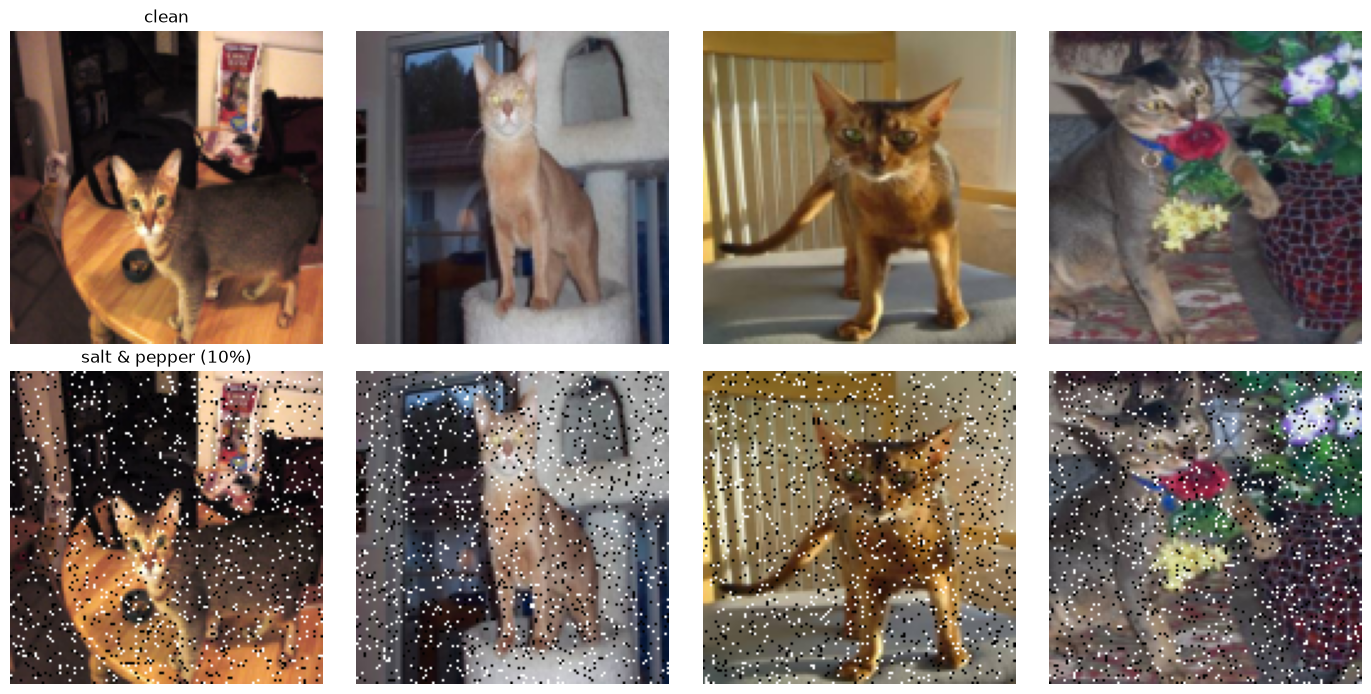

In [3]:
def add_salt_pepper(x, amount=0.10, salt_vs_pepper=0.5, generator=None):
    """x: (B, C, H, W) in [0, 1]. `amount` = fraction of pixels corrupted.
    A corrupted pixel is set to 1 (salt) or 0 (pepper) across all channels."""
    B, C, H, W = x.shape
    r = torch.rand(B, 1, H, W, device=x.device, generator=generator)
    pepper = r < amount * (1 - salt_vs_pepper)
    salt   = (r >= amount * (1 - salt_vs_pepper)) & (r < amount)
    noisy = x.masked_fill(pepper.expand_as(x), 0.0)
    noisy = noisy.masked_fill(salt.expand_as(x), 1.0)
    return noisy

# visual sanity check
x, _ = next(iter(test_loader))
x = x[:4].to(device)
fig, ax = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    ax[0, i].imshow(x[i].permute(1, 2, 0).cpu());                              ax[0, i].axis("off")
    ax[1, i].imshow(add_salt_pepper(x, 0.10)[i].permute(1, 2, 0).cpu());       ax[1, i].axis("off")
ax[0, 0].set_title("clean"); ax[1, 0].set_title("salt & pepper (10%)")
plt.tight_layout(); plt.show()

## 4. Model
The encoder has three two-convolution downsampling stages. Starting from 64 channels, the stages use 64, 128, and 256 channels and reduce 128×128 inputs to a 256-channel 16×16 bottleneck. The three-stage decoder reverses the channel widths and upsamples to the original resolution, with no skip connections.


In [4]:
class DenoisingAE(nn.Module):
    def __init__(self, base_channels=64):
        super().__init__()
        c1 = base_channels
        c2 = base_channels * 2
        c3 = base_channels * 4

        # Each stage changes channels at fixed resolution, then downsamples.
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, c1, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(c1, c1, 3, stride=2, padding=1),
            nn.ReLU(inplace=True),
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(c1, c2, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(c2, c2, 3, stride=2, padding=1),
            nn.ReLU(inplace=True),
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(c2, c3, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(c3, c3, 3, stride=2, padding=1),
            nn.ReLU(inplace=True),
        )

        # Learned upsampling reverses the three encoder downsampling stages.
        self.up3 = nn.ConvTranspose2d(c3, c3, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.dec3 = nn.Sequential(
            nn.Conv2d(c3, c3, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(c3, c2, 3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.up2 = nn.ConvTranspose2d(c2, c2, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.dec2 = nn.Sequential(
            nn.Conv2d(c2, c2, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(c2, c1, 3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.up1 = nn.ConvTranspose2d(c1, c1, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.dec1 = nn.Sequential(
            nn.Conv2d(c1, c1, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(c1, 3, 3, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        return self.enc3(self.enc2(self.enc1(x)))  # (B, 256, 16, 16) for 128x128 inputs

    def forward(self, x):
        z = self.encode(x)
        x = self.dec3(self.up3(z))
        x = self.dec2(self.up2(x))
        return self.dec1(self.up1(x))

model = DenoisingAE(base_channels=64).to(device)
print(model)
print("Params:", sum(p.numel() for p in model.parameters()))
with torch.no_grad():
    dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE, device=device)
    print("Bottleneck:", tuple(model.encode(dummy).shape), "| Output:", tuple(model(dummy).shape))


DenoisingAE(
  (enc1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (enc3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (up3): ConvTranspose2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (dec3): Sequential(
    (0): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 128, kernel_size=(3, 3), str

## 5. Training

Train with the assignment-required weighted L1 + SSIM reconstruction loss. `ALPHA` starts at 0.8; the final value should be selected with Optuna as required by the assignment. A new noise pattern is drawn every batch, while validation uses a fixed seed so epochs are comparable.


In [5]:
# Assignment Task 1 loss: alpha * L1 + (1 - alpha) * (1 - SSIM).
# 0.8 is the guideline's starting value; tune ALPHA with Optuna for the final run.
ALPHA = 0.8

def ae_loss(pred, target, alpha=ALPHA):
    l1 = F.l1_loss(pred, target)
    ssim = structural_similarity_index_measure(pred, target, data_range=1.0)
    return alpha * l1 + (1.0 - alpha) * (1.0 - ssim)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

def run_epoch(loader, train, seed=None):
    model.train(train)
    gen = None
    if seed is not None:
        gen = torch.Generator(device=device); gen.manual_seed(seed)
    total, n = 0.0, 0
    with torch.set_grad_enabled(train):
        for clean, _ in loader:
            clean = clean.to(device, non_blocking=True)
            noisy = add_salt_pepper(clean, TRAIN_NOISE, generator=gen)
            out = model(noisy)
            loss = ae_loss(out, clean)
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            total += loss.item() * clean.size(0); n += clean.size(0)
    return total / n

history = {"loss": [], "val_loss": []}
best_val = float("inf")

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr = run_epoch(train_loader, train=True)
    va = run_epoch(val_loader,   train=False, seed=SEED)
    history["loss"].append(tr); history["val_loss"].append(va)
    
    if va < best_val:
        best_val = va
        torch.save(model.state_dict(), "best_model.pt")
        
    # if epoch % 5 == 0:
    #     torch.save(model.state_dict(), f"model_epoch_{epoch}.pt")
        
    print(f"Epoch {epoch:02d}/{EPOCHS}  train={tr:.4f}  val={va:.4f}  ({time.time()-t0:.0f}s)")

model.load_state_dict(torch.load("best_model.pt"))   # restore best epoch from disk[cite: 1]
print("Best val loss:", round(best_val, 4))


/home/zaifi/genai-assignment-1/.venv/lib/python3.13/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 01/30  train=0.2238  val=0.1535  (15s)
Epoch 02/30  train=0.1342  val=0.1136  (13s)
Epoch 03/30  train=0.1070  val=0.0985  (13s)
Epoch 04/30  train=0.0946  val=0.0901  (13s)
Epoch 05/30  train=0.0856  val=0.0802  (14s)
Epoch 06/30  train=0.0815  val=0.0771  (13s)
Epoch 07/30  train=0.0777  val=0.0755  (13s)
Epoch 08/30  train=0.0765  val=0.0791  (14s)
Epoch 09/30  train=0.0748  val=0.0716  (13s)
Epoch 10/30  train=0.0725  val=0.0698  (13s)
Epoch 11/30  train=0.0693  val=0.0672  (13s)
Epoch 12/30  train=0.0674  val=0.0648  (14s)
Epoch 13/30  train=0.0696  val=0.0693  (14s)
Epoch 14/30  train=0.0657  val=0.0651  (13s)
Epoch 15/30  train=0.0651  val=0.0647  (14s)
Epoch 16/30  train=0.0657  val=0.0640  (14s)
Epoch 17/30  train=0.0638  val=0.0643  (14s)
Epoch 18/30  train=0.1015  val=0.0875  (14s)
Epoch 19/30  train=0.0794  val=0.0743  (13s)
Epoch 20/30  train=0.0717  val=0.0682  (14s)
Epoch 21/30  train=0.0676  val=0.0651  (14s)
Epoch 22/30  train=0.0661  val=0.0651  (14s)
Epoch 23/3

## 6. Loss curves

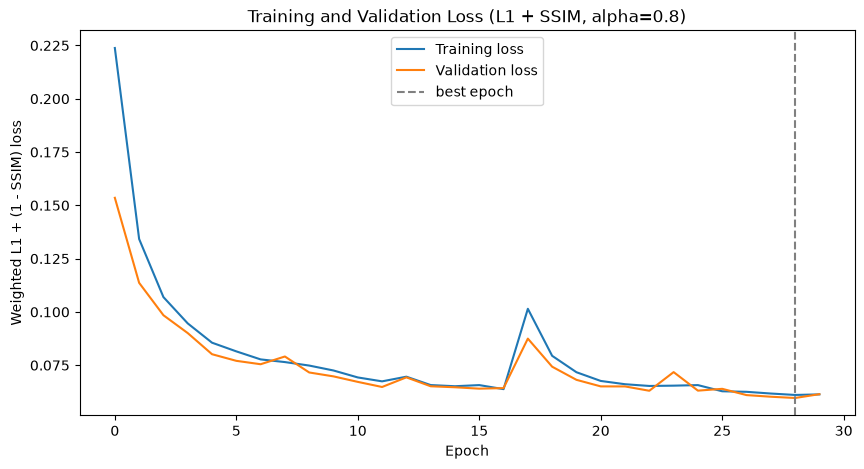

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(history["loss"], label="Training loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.axvline(int(np.argmin(history["val_loss"])), ls="--", c="gray", label="best epoch")
plt.title(f"Training and Validation Loss (L1 + SSIM, alpha={ALPHA:g})"); plt.xlabel("Epoch"); plt.ylabel("Weighted L1 + (1 - SSIM) loss")
plt.legend(); plt.show()


## 7. Test-set evaluation (PSNR / SSIM)
A fixed seed means the *same* corrupted test images are used every time you run this.

In [7]:
def psnr_batch(a, b):
    mse = ((a - b) ** 2).flatten(1).mean(1).clamp_min(1e-10)
    return 10 * torch.log10(1.0 / mse)          # per-image PSNR, data range [0, 1]

@torch.no_grad()
def evaluate(model, loader, amount, seed=123):
    model.eval()
    gen = torch.Generator(device=device); gen.manual_seed(seed)
    ssim_n = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    ssim_d = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    p_n, p_d = [], []
    for clean, _ in loader:
        clean = clean.to(device)
        noisy = add_salt_pepper(clean, amount, generator=gen)
        den   = model(noisy)
        p_n.append(psnr_batch(noisy, clean)); p_d.append(psnr_batch(den, clean))
        ssim_n.update(noisy, clean);          ssim_d.update(den, clean)
    return dict(psnr_noisy=torch.cat(p_n).mean().item(), psnr_denoised=torch.cat(p_d).mean().item(),
                ssim_noisy=ssim_n.compute().item(),      ssim_denoised=ssim_d.compute().item())

res = evaluate(model, test_loader, TRAIN_NOISE)
print(f"Noise density: {TRAIN_NOISE:.0%}")
print(f"PSNR  noisy: {res['psnr_noisy']:.2f} dB  ->  denoised: {res['psnr_denoised']:.2f} dB")
print(f"SSIM  noisy: {res['ssim_noisy']:.4f}     ->  denoised: {res['ssim_denoised']:.4f}")

Noise density: 10%
PSNR  noisy: 14.91 dB  ->  denoised: 24.12 dB
SSIM  noisy: 0.2647     ->  denoised: 0.8815


## 8. Visual results

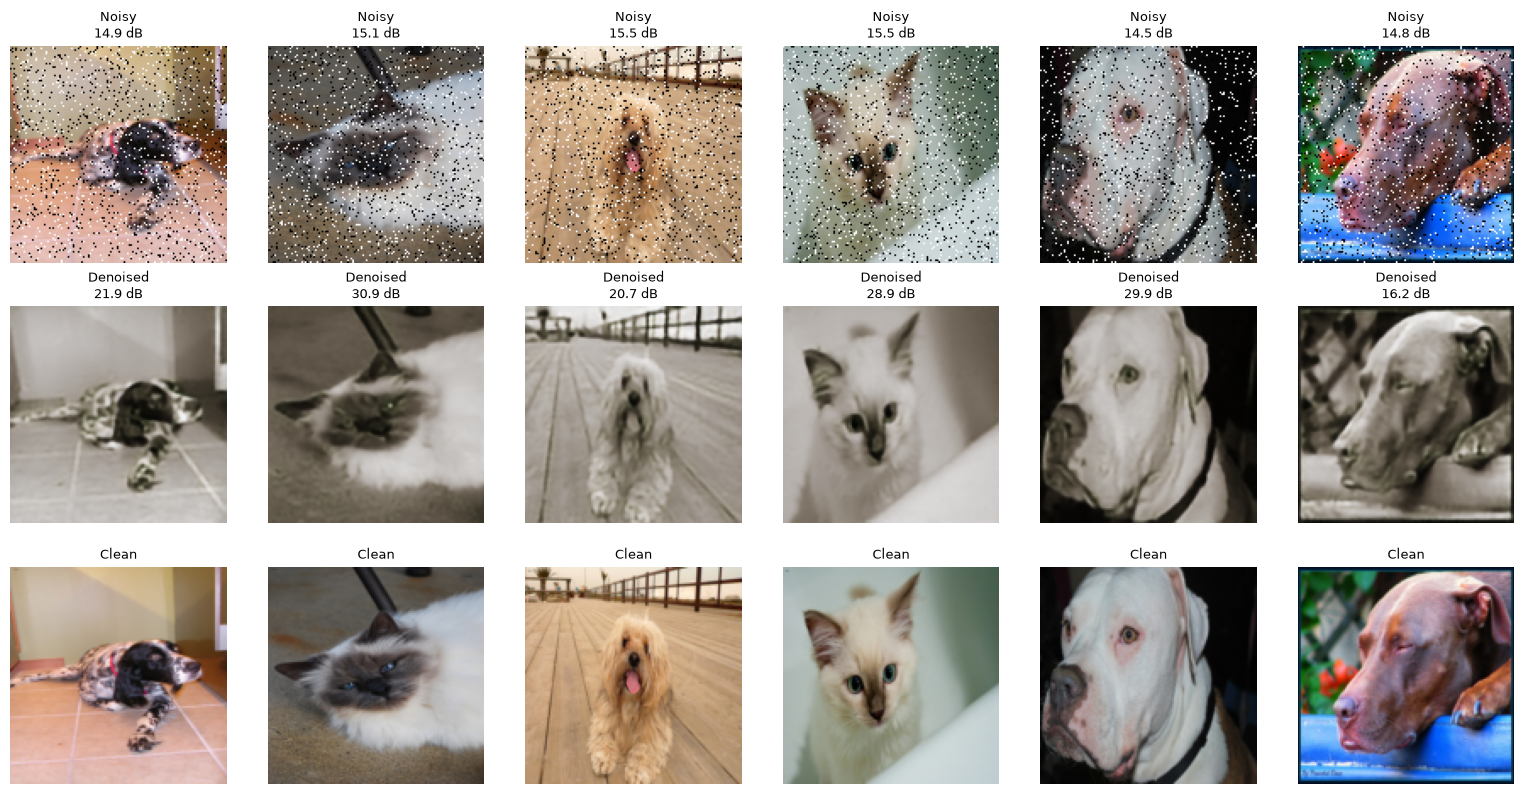

In [8]:
@torch.no_grad()
def show_results(model, dataset, amount=TRAIN_NOISE, n=6, seed=7):
    model.eval()
    idx = random.Random(seed).sample(range(len(dataset)), n)
    clean = torch.stack([dataset[i][0] for i in idx]).to(device)
    gen = torch.Generator(device=device); gen.manual_seed(seed)
    noisy = add_salt_pepper(clean, amount, generator=gen)
    den = model(noisy)
    p_n, p_d = psnr_batch(noisy, clean), psnr_batch(den, clean)

    rows = [("Noisy", noisy, p_n), ("Denoised", den, p_d), ("Clean", clean, None)]
    fig, ax = plt.subplots(3, n, figsize=(2.6 * n, 8))
    for r, (name, imgs, p) in enumerate(rows):
        for c in range(n):
            ax[r, c].imshow(imgs[c].permute(1, 2, 0).clamp(0, 1).cpu()); ax[r, c].axis("off")
            if p is not None: ax[r, c].set_title(f"{name}\n{p[c]:.1f} dB", fontsize=9)
            else:             ax[r, c].set_title(name, fontsize=9)
    plt.tight_layout(); plt.show()

show_results(model, test_ds)

## 9. Robustness: different noise densities
The model was trained at one density. This shows how it behaves on lighter and heavier noise.

  2% | PSNR 21.93 -> 24.16 dB | SSIM 0.689 -> 0.887
  5% | PSNR 17.93 -> 24.16 dB | SSIM 0.443 -> 0.885
 10% | PSNR 14.91 -> 24.12 dB | SSIM 0.265 -> 0.881
 20% | PSNR 11.91 -> 23.94 dB | SSIM 0.140 -> 0.866
 30% | PSNR 10.14 -> 23.45 dB | SSIM 0.090 -> 0.831
 50% | PSNR  7.93 -> 20.26 dB | SSIM 0.044 -> 0.644


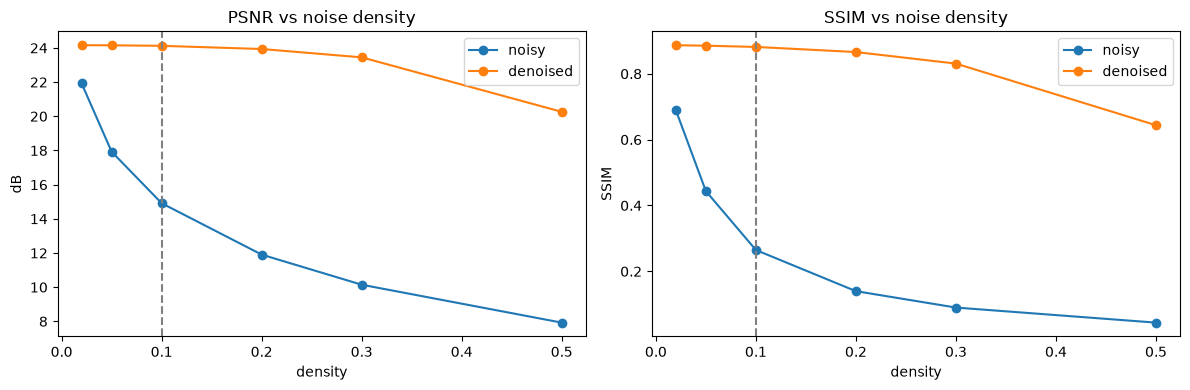

In [9]:
levels = [0.02, 0.05, 0.10, 0.20, 0.30, 0.50]
rows = []
for a in levels:
    r = evaluate(model, test_loader, a)
    rows.append((a, r["psnr_noisy"], r["psnr_denoised"], r["ssim_noisy"], r["ssim_denoised"]))
    print(f"{a:>4.0%} | PSNR {r['psnr_noisy']:5.2f} -> {r['psnr_denoised']:5.2f} dB | SSIM {r['ssim_noisy']:.3f} -> {r['ssim_denoised']:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(levels, [r[1] for r in rows], "o-", label="noisy");    ax[0].plot(levels, [r[2] for r in rows], "o-", label="denoised")
ax[0].axvline(TRAIN_NOISE, ls="--", c="gray"); ax[0].set(title="PSNR vs noise density", xlabel="density", ylabel="dB"); ax[0].legend()
ax[1].plot(levels, [r[3] for r in rows], "o-", label="noisy");    ax[1].plot(levels, [r[4] for r in rows], "o-", label="denoised")
ax[1].axvline(TRAIN_NOISE, ls="--", c="gray"); ax[1].set(title="SSIM vs noise density", xlabel="density", ylabel="SSIM"); ax[1].legend()
plt.tight_layout(); plt.show()

## 10. Baseline: 3×3 median filter
Median filtering is the classic fix for salt & pepper noise. The autoencoder should beat or at least match it; if not, it needs more training or capacity.

Noisy        : 14.85 dB
Median 3x3   : 31.05 dB
Autoencoder  : 24.22 dB


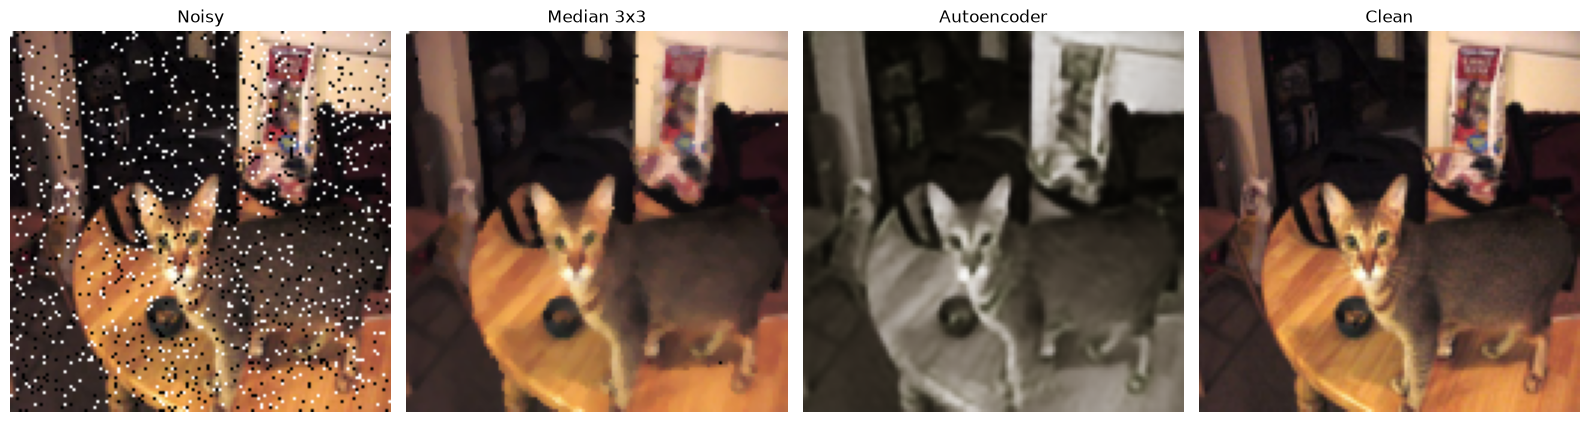

In [10]:
from scipy.ndimage import median_filter

N = 200  # number of test images (CPU filtering is slow)
gen = torch.Generator(device=device); gen.manual_seed(123)
clean = torch.stack([test_ds[i][0] for i in range(N)]).to(device)
noisy = add_salt_pepper(clean, TRAIN_NOISE, generator=gen)

with torch.no_grad():
    model.eval()
    ae_out = torch.cat([model(noisy[i:i+32]) for i in range(0, N, 32)])

med = np.stack([median_filter(img, size=(1, 3, 3)) for img in noisy.cpu().numpy()])   # (N, C, H, W)
med = torch.from_numpy(med).to(device)

print(f"Noisy        : {psnr_batch(noisy, clean).mean():.2f} dB")
print(f"Median 3x3   : {psnr_batch(med,   clean).mean():.2f} dB")
print(f"Autoencoder  : {psnr_batch(ae_out, clean).mean():.2f} dB")

fig, ax = plt.subplots(1, 4, figsize=(16, 4.5))
for a, (t, im) in zip(ax, [("Noisy", noisy[0]), ("Median 3x3", med[0]), ("Autoencoder", ae_out[0]), ("Clean", clean[0])]):
    a.imshow(im.permute(1, 2, 0).clamp(0, 1).cpu()); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

## 11. Save / load

In [11]:
torch.save({"state_dict": model.state_dict(), "img_size": IMG_SIZE, "train_noise": TRAIN_NOISE}, "dae_saltpepper_pets.pt")

# reload and verify
ckpt = torch.load("dae_saltpepper_pets.pt", map_location=device)
model2 = DenoisingAE(base_channels=64).to(device); model2.load_state_dict(ckpt["state_dict"]); model2.eval()
print("Reloaded OK. Test PSNR:", round(evaluate(model2, test_loader, TRAIN_NOISE)["psnr_denoised"], 2), "dB")


Reloaded OK. Test PSNR: 24.12 dB


## Next steps
- Train with a **random** density per batch (e.g. `amount = random.uniform(0.05, 0.4)`) to improve robustness in section 9.
- Make it a U-Net by concatenating encoder feature maps into the decoder, then re-run sections 7–10 to compare against this baseline.
- Use Optuna to select `ALPHA` for the weighted L1 + SSIM objective, as required by the assignment.